In [1]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

ROOT     = Path("/scratch3/plant-traits-v2/data")
SKCV_DIR = ROOT / "22km" / "skcv_splits"
FIG_DIR  = ROOT / "22km" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Grid resolution in metres (22km)
PIXEL_SIZE_M  = 22000
PIXEL_AREA_KM2 = (PIXEL_SIZE_M / 1000) ** 2   # 484 km²

# Use one trait — the hexagon assignment is the same for all traits
# (fold is purely spatial, not trait-specific)
parquet_files = sorted(SKCV_DIR.glob("*.parquet"))
print(f"Found {len(parquet_files)} parquet files")
print(f"Pixel area: {PIXEL_AREA_KM2:.0f} km²")

/tmp/ipykernel_4053947/1321472932.py:5: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy import ndimage


Found 37 parquet files
Pixel area: 484 km²


In [2]:
# Load first parquet (hex grid is identical across all traits)
example_parquet = parquet_files[0]
df = pd.read_parquet(example_parquet)
print(f"Loaded: {example_parquet.name}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Fold values: {sorted(df['fold'].unique())}")
print(f"Total pixels: {len(df):,}")
print()
print(df.head())

Loaded: X1080_mean.parquet
Shape: (130527, 3)
Columns: ['x', 'y', 'fold']
Fold values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Total pixels: 130,527

              x             y  fold
0 -1.735652e+07  6.957519e+06     3
1 -1.735652e+07  6.935536e+06     3
2 -1.735652e+07  6.847605e+06     3
3 -1.735652e+07  6.825622e+06     3
4 -1.735652e+07  6.781657e+06     3


In [3]:
# ── Reconstruct the fold raster from x,y coordinates ─────────────────────────
# EPSG:6933: x increases right, y increases up
# Raster row = (y_max - y) / pixel_size

x_coords = df['x'].values
y_coords = df['y'].values

x_min, x_max = x_coords.min(), x_coords.max()
y_min, y_max = y_coords.min(), y_coords.max()

print(f"X range: {x_min/1e6:.2f} to {x_max/1e6:.2f} million metres")
print(f"Y range: {y_min/1e6:.2f} to {y_max/1e6:.2f} million metres")

# Infer pixel size from coordinate spacing
x_unique = np.sort(np.unique(x_coords))
y_unique = np.sort(np.unique(y_coords))
dx = np.median(np.diff(x_unique))
dy = np.median(np.diff(y_unique))
print(f"\nInferred pixel size: dx={dx/1000:.1f} km, dy={dy/1000:.1f} km")

# Build 2D fold raster
ncols = int(round((x_max - x_min) / dx)) + 1
nrows = int(round((y_max - y_min) / dy)) + 1

col_idx = np.round((x_coords - x_min) / dx).astype(int)
row_idx = np.round((y_max - y_coords) / dy).astype(int)  # flip y

fold_raster = np.full((nrows, ncols), -1, dtype=np.int8)
fold_raster[row_idx, col_idx] = df['fold'].values

print(f"\nFold raster shape: {fold_raster.shape}")
print(f"Pixels with data:  {np.sum(fold_raster >= 0):,}")
print(f"Empty pixels:      {np.sum(fold_raster < 0):,}")

X range: -17.36 to 17.36 million metres
Y range: -6.80 to 7.29 million metres

Inferred pixel size: dx=22.0 km, dy=22.0 km

Fold raster shape: (642, 1578)
Pixels with data:  130,527
Empty pixels:      882,549


In [4]:
all_hex_sizes_pixels = []   # pixel counts per hexagon
all_hex_sizes_km2    = []   # area in km² per hexagon
hex_stats_per_fold   = []

struct = ndimage.generate_binary_structure(2, 1)  # 4-connectivity

for fold_id in range(5):
    # Binary mask: True where this fold's pixels are
    fold_mask = (fold_raster == fold_id)
    
    # Label connected components
    labeled, n_components = ndimage.label(fold_mask, structure=struct)
    
    # Count pixels in each component
    component_sizes = np.bincount(labeled.ravel())[1:]  # skip background (label 0)
    component_areas_km2 = component_sizes * PIXEL_AREA_KM2
    
    all_hex_sizes_pixels.extend(component_sizes.tolist())
    all_hex_sizes_km2.extend(component_areas_km2.tolist())
    
    hex_stats_per_fold.append({
        'fold':         fold_id,
        'n_hexagons':   n_components,
        'n_pixels':     int(fold_mask.sum()),
        'min_px':       int(component_sizes.min()),
        'max_px':       int(component_sizes.max()),
        'mean_px':      float(component_sizes.mean()),
        'median_px':    float(np.median(component_sizes)),
        'min_km2':      float(component_areas_km2.min()),
        'max_km2':      float(component_areas_km2.max()),
        'mean_km2':     float(component_areas_km2.mean()),
        'median_km2':   float(np.median(component_areas_km2)),
        'total_area_km2': float(component_areas_km2.sum()),
    })
    
    print(f"Fold {fold_id}: {n_components:4d} hexagons  "
          f"pixels/hex: min={component_sizes.min():4d} "
          f"mean={component_sizes.mean():6.1f} "
          f"max={component_sizes.max():4d}  "
          f"area km²: min={component_areas_km2.min():7.0f} "
          f"mean={component_areas_km2.mean():9.0f} "
          f"max={component_areas_km2.max():9.0f}")

all_hex_sizes_pixels = np.array(all_hex_sizes_pixels)
all_hex_sizes_km2    = np.array(all_hex_sizes_km2)
stats_df = pd.DataFrame(hex_stats_per_fold)

Fold 0: 2375 hexagons  pixels/hex: min=   1 mean=  10.4 max=2323  area km²: min=    484 mean=     5049 max=  1124332
Fold 1: 2671 hexagons  pixels/hex: min=   1 mean=  10.9 max=5239  area km²: min=    484 mean=     5265 max=  2535676
Fold 2: 2238 hexagons  pixels/hex: min=   1 mean=  13.2 max=5829  area km²: min=    484 mean=     6400 max=  2821236
Fold 3: 1963 hexagons  pixels/hex: min=   1 mean=  13.8 max=2033  area km²: min=    484 mean=     6668 max=   983972
Fold 4: 2309 hexagons  pixels/hex: min=   1 mean=   8.7 max=2520  area km²: min=    484 mean=     4204 max=  1219680


In [5]:
print('=' * 60)
print('HEXAGON SIZE SUMMARY (across all folds)')
print('=' * 60)
print(f'Total hexagons identified:  {len(all_hex_sizes_pixels):,}')
print()
print('── In pixels (1 pixel = 22km × 22km) ──')
print(f'  Min    : {all_hex_sizes_pixels.min():,} pixels')
print(f'  Max    : {all_hex_sizes_pixels.max():,} pixels')
print(f'  Mean   : {all_hex_sizes_pixels.mean():,.1f} pixels')
print(f'  Median : {np.median(all_hex_sizes_pixels):,.1f} pixels')
print(f'  Std    : {all_hex_sizes_pixels.std():,.1f} pixels')
print()
print('── In area (km²) ──')
print(f'  Min    : {all_hex_sizes_km2.min():>12,.0f} km²')
print(f'  Max    : {all_hex_sizes_km2.max():>12,.0f} km²')
print(f'  Mean   : {all_hex_sizes_km2.mean():>12,.0f} km²')
print(f'  Median : {np.median(all_hex_sizes_km2):>12,.0f} km²')
print(f'  Std    : {all_hex_sizes_km2.std():>12,.0f} km²')
print()
print('── Equivalent circle diameter (from mean area) ──')
mean_area_m2 = all_hex_sizes_km2.mean() * 1e6
equiv_radius_km = np.sqrt(mean_area_m2 / np.pi) / 1000
equiv_diam_km   = 2 * equiv_radius_km
print(f'  Mean area equivalent diameter: {equiv_diam_km:,.0f} km')
print(f'  (This approximates the spatial autocorrelation range used)')
print()
print('── Per-fold breakdown ──')
print(stats_df[['fold','n_hexagons','min_km2','mean_km2','median_km2','max_km2']]
      .to_string(index=False, float_format=lambda x: f'{x:,.0f}'))

HEXAGON SIZE SUMMARY (across all folds)
Total hexagons identified:  11,556

── In pixels (1 pixel = 22km × 22km) ──
  Min    : 1 pixels
  Max    : 5,829 pixels
  Mean   : 11.3 pixels
  Median : 1.0 pixels
  Std    : 110.2 pixels

── In area (km²) ──
  Min    :          484 km²
  Max    :    2,821,236 km²
  Mean   :        5,467 km²
  Median :          484 km²
  Std    :       53,346 km²

── Equivalent circle diameter (from mean area) ──
  Mean area equivalent diameter: 83 km
  (This approximates the spatial autocorrelation range used)

── Per-fold breakdown ──
 fold  n_hexagons  min_km2  mean_km2  median_km2   max_km2
    0        2375      484     5,049         484 1,124,332
    1        2671      484     5,265         484 2,535,676
    2        2238      484     6,400         484 2,821,236
    3        1963      484     6,668         484   983,972
    4        2309      484     4,204         484 1,219,680


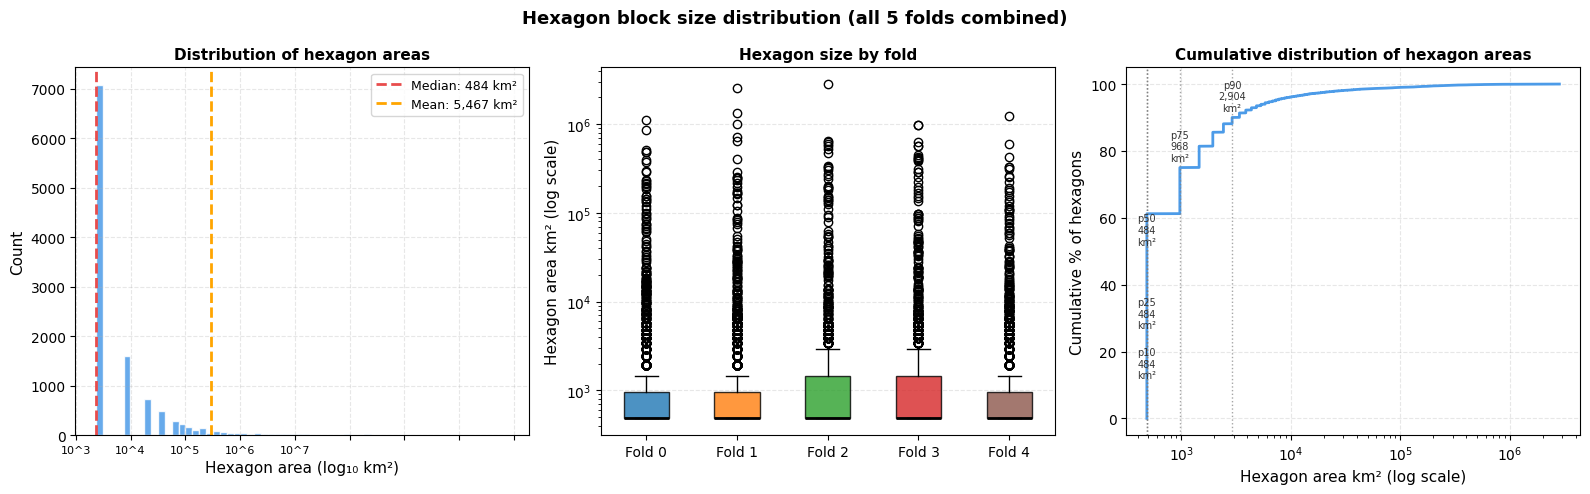

Saved: hex_size_distribution.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hexagon block size distribution (all 5 folds combined)',
             fontsize=13, fontweight='bold')

# ── Panel 1: histogram of hexagon areas ──────────────────────────────────────
ax = axes[0]
# Use log scale because distribution is likely very right-skewed
log_areas = np.log10(all_hex_sizes_km2[all_hex_sizes_km2 > 0])
ax.hist(log_areas, bins=60, color='#4C9BE8', alpha=0.85, edgecolor='white')
ax.axvline(np.log10(np.median(all_hex_sizes_km2)), color='#E84C4C',
           linestyle='--', linewidth=2, label=f'Median: {np.median(all_hex_sizes_km2):,.0f} km²')
ax.axvline(np.log10(all_hex_sizes_km2.mean()), color='orange',
           linestyle='--', linewidth=2, label=f'Mean: {all_hex_sizes_km2.mean():,.0f} km²')
ax.set_xlabel('Hexagon area (log₁₀ km²)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of hexagon areas', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

# Add x-axis tick labels in real km² units
xticks = ax.get_xticks()
ax.set_xticklabels([f'10^{t:.0f}' for t in xticks], fontsize=8)

# ── Panel 2: boxplot per fold ─────────────────────────────────────────────────
ax = axes[1]
fold_areas = []
for fold_id in range(5):
    fold_mask = (fold_raster == fold_id)
    labeled, _ = ndimage.label(fold_mask, structure=struct)
    sizes = np.bincount(labeled.ravel())[1:] * PIXEL_AREA_KM2
    fold_areas.append(sizes)

bp = ax.boxplot(fold_areas, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
colors = plt.cm.tab10(np.linspace(0, 0.5, 5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_yscale('log')
ax.set_xticklabels([f'Fold {i}' for i in range(5)])
ax.set_ylabel('Hexagon area km² (log scale)', fontsize=11)
ax.set_title('Hexagon size by fold', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# ── Panel 3: cumulative distribution ─────────────────────────────────────────
ax = axes[2]
sorted_areas = np.sort(all_hex_sizes_km2)
cdf = np.arange(1, len(sorted_areas) + 1) / len(sorted_areas)
ax.semilogx(sorted_areas, cdf * 100, color='#4C9BE8', linewidth=2)

# Mark p10, p25, median, p75, p90
for pct in [10, 25, 50, 75, 90]:
    val = np.percentile(all_hex_sizes_km2, pct)
    ax.axvline(val, color='grey', linestyle=':', alpha=0.7, linewidth=1)
    ax.text(val, pct + 2, f'p{pct}\n{val:,.0f}\nkm²',
            fontsize=7, ha='center', color='#333333')

ax.set_xlabel('Hexagon area km² (log scale)', fontsize=11)
ax.set_ylabel('Cumulative % of hexagons', fontsize=11)
ax.set_title('Cumulative distribution of hexagon areas', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(FIG_DIR / 'hex_size_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: hex_size_distribution.png')

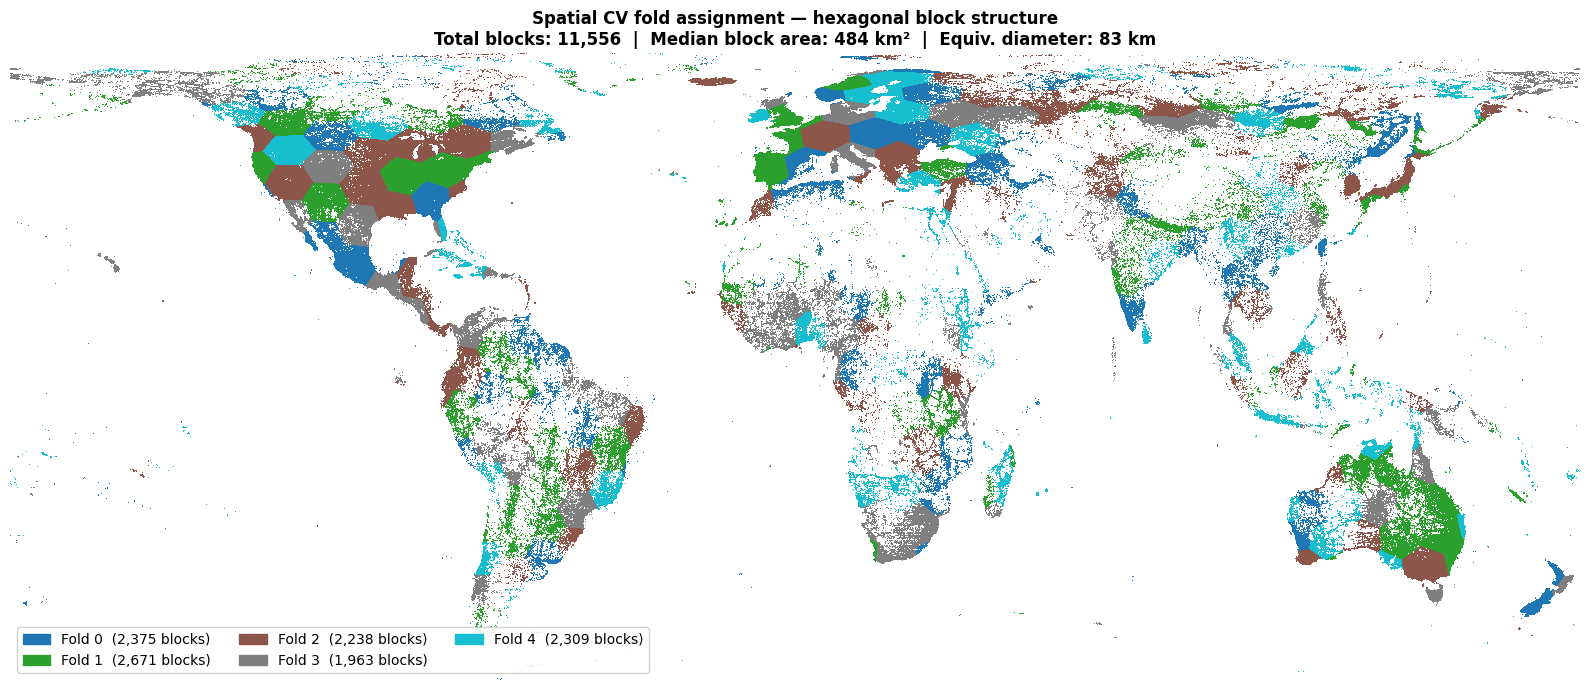

Saved: hex_fold_map.png


In [7]:
# ── Global map of hexagon blocks coloured by fold ────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

display_raster = fold_raster.astype(float)
display_raster[display_raster < 0] = np.nan

cmap_fold = plt.cm.get_cmap('tab10', 5)
norm_fold = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 5)

ax.imshow(display_raster, cmap=cmap_fold, norm=norm_fold,
          interpolation='nearest', aspect='auto')

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=cmap_fold(i), label=f'Fold {i}  ({stats_df.loc[i,"n_hexagons"]:,} blocks)')
           for i in range(5)]
ax.legend(handles=patches, loc='lower left', fontsize=10,
          framealpha=0.9, ncol=3)
ax.set_title('Spatial CV fold assignment — hexagonal block structure\n'
             f'Total blocks: {len(all_hex_sizes_pixels):,}  |  '
             f'Median block area: {np.median(all_hex_sizes_km2):,.0f} km²  |  '
             f'Equiv. diameter: {equiv_diam_km:,.0f} km',
             fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / 'hex_fold_map.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: hex_fold_map.png')

In [8]:
consistency_rows = []

for pq in parquet_files:
    d = pd.read_parquet(pq)
    fold_counts = d['fold'].value_counts().sort_index()
    row = {'trait': pq.stem, 'total': len(d)}
    for fold_id in range(5):
        row[f'fold_{fold_id}'] = int(fold_counts.get(fold_id, 0))
    consistency_rows.append(row)

cons_df = pd.DataFrame(consistency_rows)

print('Pixel counts per fold per trait:')
print(cons_df.to_string(index=False))
print()

fold_cols = [f'fold_{i}' for i in range(5)]
print('── Fold count statistics across traits ──')
for col in fold_cols:
    print(f"  {col}: min={cons_df[col].min():,}  "
          f"max={cons_df[col].max():,}  "
          f"std={cons_df[col].std():.1f}")

print()
if cons_df[fold_cols].std().max() < 100:
    print('Fold assignment is CONSISTENT across all traits (std < 100 pixels).')
else:
    print('WARNING: Fold assignment varies across traits — may be trait-specific splits.')

Pixel counts per fold per trait:
     trait  total  fold_0  fold_1  fold_2  fold_3  fold_4
X1080_mean 130527   24777   29055   29595   27046   20054
 X138_mean 130558   26869   28860   22354   31596   20879
  X13_mean 130229   28371   22032   25742   27273   26811
 X144_mean 131318   25230   31116   23329   20675   30968
 X145_mean 131489   16212   30498   29028   32174   23577
 X146_mean 130722   29174   22802   26854   27723   24169
  X14_mean 130489   35179   21700   27158   25760   20692
  X15_mean 130174   25141   31953   22748   31324   19008
 X163_mean 130655   11350   26146   16818   51982   24359
 X169_mean 129297   21438   14288   29651   42049   21871
  X21_mean 129854   24265   22507   30094   27408   25580
 X223_mean 130816   22630   22160   27034   27230   31762
 X224_mean 130791   23751   26952   24871   23515   31702
 X237_mean 130999   23810   37569   28504   20608   20508
  X26_mean 133077   27232   21805   30042   26244   27754
  X27_mean 132082   34755   25886   238